In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, Sequential
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import os

In [2]:
batch_size = 32
img_height = 224
img_width = 224

In [3]:
train_dir = "apto/train"
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  labels="inferred",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 294 files belonging to 2 classes.


In [4]:
test_dir = "apto/test"
val_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  labels="inferred",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 97 files belonging to 2 classes.


In [5]:
class_names = train_ds.class_names
print(class_names)

['apples', 'tomatoes']


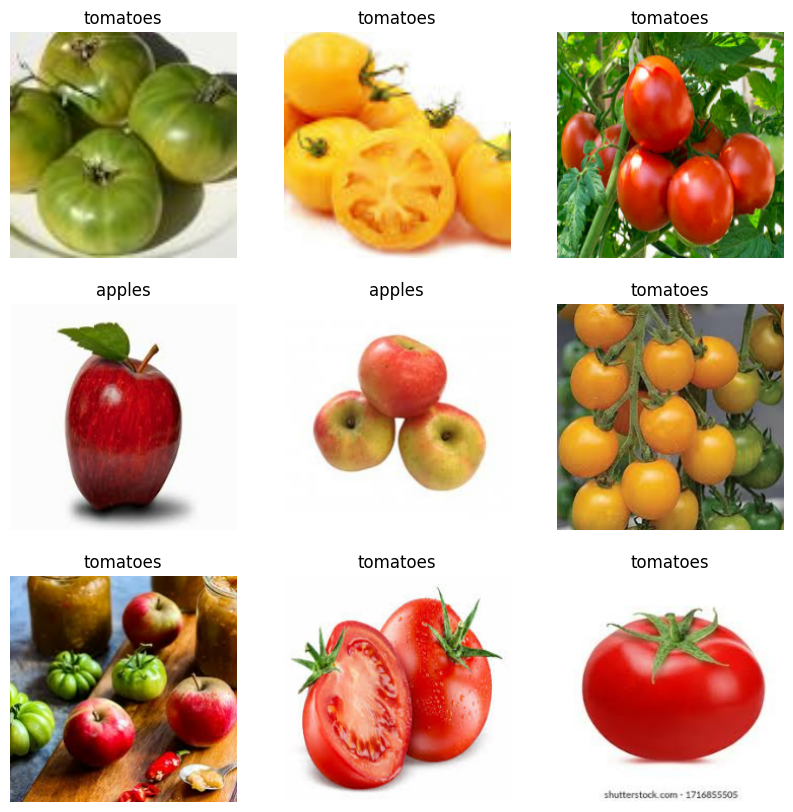

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [7]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
normalization_layer = layers.Rescaling(1./255)

In [10]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [11]:
num_classes = len(class_names)
print(num_classes)

2


In [12]:
num_classes = len(class_names)

model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

c:\Users\yorba\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [14]:
epochs=20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 824ms/step - accuracy: 0.5000 - loss: 1.4496 - val_accuracy: 0.5567 - val_loss: 0.6838
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 477ms/step - accuracy: 0.5510 - loss: 0.6861 - val_accuracy: 0.5567 - val_loss: 0.6769
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 432ms/step - accuracy: 0.5578 - loss: 0.6729 - val_accuracy: 0.6598 - val_loss: 0.6610
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 505ms/step - accuracy: 0.6156 - loss: 0.6674 - val_accuracy: 0.5567 - val_loss: 0.7265
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 475ms/step - accuracy: 0.6259 - loss: 0.6803 - val_accuracy: 0.6701 - val_loss: 0.6548
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 443ms/step - accuracy: 0.6395 - loss: 0.6398 - val_accuracy: 0.5670 - val_loss: 0.6747
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 499ms/step - accuracy: 0.6735 - loss: 0.6274 - val_accuracy: 0.6907 - val_loss: 0.5896
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 413ms/step - accuracy: 0.6565 - loss: 0.6024 - val_accuracy: 0

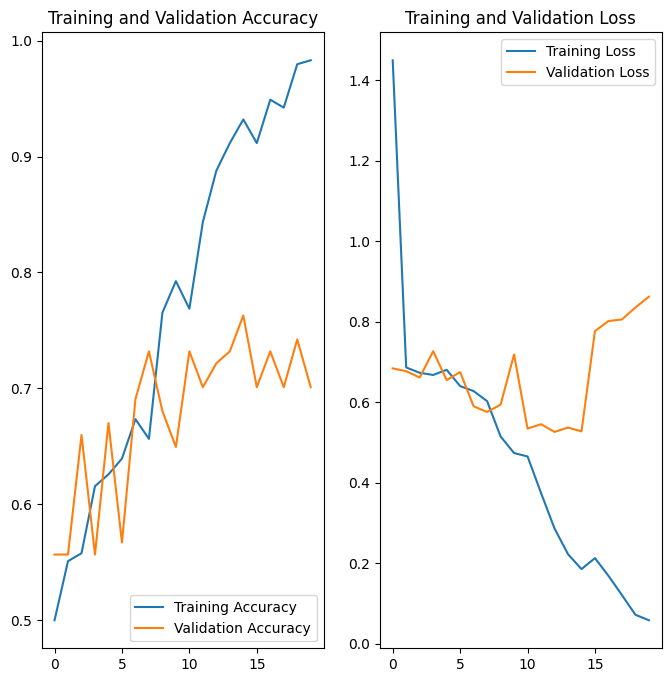

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [18]:
local_path = os.path.abspath("purpto.jpg")

img = tf.keras.utils.load_img(
    local_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
This image most likely belongs to tomatoes with a 98.24 percent confidence.


In [17]:
model.save("apto.keras")